# PointDiT inference with a converted LiteRT (`.tflite`) denoiser

Runs the real image -> point-map generation pipeline with the per-step denoiser network
swapped from PyTorch to a converted `.tflite` model (see `convert_denoiser_litert.py` /
`quantize_denoiser_*.py` in this directory for how those files are produced, and
`../../README.md`'s "LiteRT / on-device inference" section for the full accuracy/latency
comparison across all 8 quantization configs).

**What's ported vs. imported.** The frozen DINOv3 image encoder still runs in real PyTorch --
it's the same code path `denoiser.py`'s `Denoiser.generate()` uses (`extract_y_embedding`,
called once, its output cached and reused every step -- see `research-repo-bringup` skill
step 10). What changes is the *denoiser* call inside the euler-integration loop: instead of
`self.net(z, t, labels, cached_y_emb=...)`, each step below calls the `.tflite` interpreter
with the same four tensors. The loop structure itself
(`Denoiser.generate()`/`_euler_step()`/`_forward_sample()` in `denoiser.py`) is copied
verbatim, not re-derived, precisely so this stays a faithful port rather than a
plausible-looking rewrite -- the one thing that changes is named in a comment at that line.

**Why the encoder stays PyTorch, not also converted**: `cached_y_emb` is a real, separate
graph *input* to every one of these `.tflite` exports (confirmed in `research-repo-bringup`
skill step 13's licensing check) -- the DINOv3 encoder was never part of the conversion, so
it's still needed locally, under the same gated-weights terms as the rest of this repo (see
`../../README.md`'s Installation section). Only the denoiser transformer -- the
Apache-2.0-licensed, HF-hosted part -- was converted.

## 1. Setup and imports

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import torch
from PIL import Image

sys.path.insert(0, ".")  # run this notebook from the repo root
from main import get_args_parser
from denoiser import Denoiser
from util.viz_depth import viz_depth_tensor
from util.viz_pointcloud import save_single_point_cloud

/home/kaiser/.conda/envs/pointdit_litert/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration (parameters)

`tflite_path` defaults to the weight-only int8 export -- the best-accuracy quantized
variant measured in the benchmark (max abs diff 0.007 vs. the PyTorch-GPU reference; see the
README table). Point it at any of the other 7 converted models in `models/` to reproduce a
different row of that table end-to-end, not just the isolated per-step diff.

In [2]:
image_path = "assets/pinecone_bench/IMG_7261.png"  # a single real image, held out from calibration
model_size = "L"  # "L" (PointDiT-L/16) or "B" (PointDiT-B/16)
checkpoint = "pretrained/pointditl-512-mixdata-nodinov3-240c1a4f.pth"
tflite_path = "tools/litert/models/pointdit_l16_denoiser_step_weightonly.tflite"
img_size = 512
num_sampling_steps = 3
out_dir = "generation/litert_inference"

In [3]:
assert model_size in ("L", "B")
Path(out_dir).mkdir(parents=True, exist_ok=True)

## 3. Build the real Denoiser, load the checkpoint + frozen DINOv3 encoder

Same loading sequence as `export_web_demo_inputs.py` in this directory (already verified
against the full `main.py`/`engine.py` pipeline in `notebooks/run_pointdit_demo_standalone.py`
-- bit-identical depth PNGs and point-cloud vertices). `args.pretrained` is required by
`get_args_parser()`'s own validation even though we load the checkpoint by hand below (not
via `main.py`'s `--resume`/`--pretrained` branch), so it's passed for consistency, not read.

In [4]:
args = get_args_parser().parse_args([
    "--model", f"PointDiT-{model_size}/16",
    "--feature_embedding_type", f"dinov3_vit{model_size.lower()}16",
    "--proj_dropout", "0.0", "--evaluate_gen", "--img_size", str(img_size),
    "--num_sampling_steps", str(num_sampling_steps), "--pretrained", checkpoint,
])
model = Denoiser(args)
model.eval()

loaded_checkpoint = torch.load(checkpoint, map_location="cpu", weights_only=False)
incompatible = model.load_state_dict(loaded_checkpoint["model"], strict=False)
# The released checkpoints ship without the frozen DINOv3 encoder (gated weights, not
# redistributable) -- those keys are expected to be missing here; every other mismatch is fatal.
missing = [k for k in incompatible.missing_keys if not k.startswith("net.y_embedder.")]
assert not missing and not incompatible.unexpected_keys, (missing, incompatible.unexpected_keys)

dinov3_dir = Path("pretrained/dinov3")
sha = {"L": "8aa4cbdd", "B": "73cec8be"}[model_size]
dinov3_ckpt = dinov3_dir / f"dinov3_vit{model_size.lower()}16_pretrain_lvd1689m-{sha}.pth"
assert dinov3_ckpt.exists(), (
    f"{dinov3_ckpt} not found. DINOv3 weights are gated -- request access at "
    f"https://github.com/facebookresearch/dinov3 and place them here (see README Installation)."
)
model.net.y_embedder.load_state_dict(torch.load(dinov3_ckpt, map_location="cpu"), strict=True)

# EMA weights (the released checkpoints ship model_ema1 only -- see denoiser.py's real
# `has_ema` branch and the standalone notebook's section 4b for the full main.py-equivalent
# handling; this is the same simplified swap already used and verified in export_web_demo_inputs.py)
ema_state_dict1 = loaded_checkpoint["model_ema1"]
sd = dict(model.state_dict())
for name, _ in model.named_parameters():
    if name in ema_state_dict1:
        sd[name] = ema_state_dict1[name]
model.load_state_dict(sd)
print(f"Loaded PointDiT-{model_size}/16 + DINOv3-vit{model_size.lower()}16, EMA weights applied.")

Loaded PointDiT-L/16 + DINOv3-vitl16, EMA weights applied.


## 4. Load the image and compute `cached_y_emb` once (the real, frozen encoder pass)

`extract_y_embedding` is the exact call `Denoiser.generate()` makes once per image
(`denoiser.py` line ~200) before entering the euler loop -- reused verbatim here, not
reimplemented, since it's real PyTorch throughout (no LiteRT involved at this step).

In [5]:
img = Image.open(image_path).convert("RGB").resize((img_size, img_size), Image.BILINEAR)
arr = np.asarray(img, dtype=np.float32) / 255.0
labels = torch.from_numpy((arr.transpose(2, 0, 1)[None] * 2 - 1).astype(np.float32))  # [-1, 1], NCHW

h_patches = w_patches = img_size // model.net.patch_size
with torch.no_grad():
    cached_y_emb = model.net.extract_y_embedding(labels, h_patches, w_patches)
print("cached_y_emb:", tuple(cached_y_emb.shape))

cached_y_emb: (1, 1024, 4096)


## 5. Load the converted `.tflite` denoiser

In [6]:
from ai_edge_litert.interpreter import Interpreter

interp = Interpreter(model_path=tflite_path, num_threads=4)
interp.allocate_tensors()
in_details = {d["name"]: d for d in interp.get_input_details()}
out_details = interp.get_output_details()[0]
print(f"Loaded {tflite_path}")
print("inputs:", {k: (d["shape"].tolist(), str(d["dtype"])) for k, d in in_details.items()})

Loaded tools/litert/models/pointdit_l16_denoiser_step_weightonly.tflite
inputs: {'serving_default_args_0': ([1, 3, 512, 512], "<class 'numpy.float32'>"), 'serving_default_args_1': ([1], "<class 'numpy.float32'>"), 'serving_default_args_2': ([1, 3, 512, 512], "<class 'numpy.float32'>"), 'serving_default_cached_y_emb': ([1, 1024, 4096], "<class 'numpy.float32'>")}


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 6. The real euler-integration sampling loop, denoiser calls routed to `.tflite`

This is `denoiser.py`'s `Denoiser.generate()` / `_euler_step()` / `_forward_sample()`
(lines 158-228), copied verbatim except for exactly one line -- `_forward_sample`'s
`self.net(z, t, labels, cached_y_emb=...)` PyTorch call becomes `litert_denoiser_step(...)`
below, marked at that line. Everything else (the `timesteps = linspace(0, 1, steps+1)`
schedule, the `range(steps - 1)` loop with a separately-guarded final step, the
`v = (x_cond - z) / (1 - t).clamp_min(eps)` velocity formula, the euler update
`z + (t_next - t) * v_pred`) is the same math, unchanged.

int8-static's model is the one variant whose input/output tensors are themselves real
int8 (not float32 with int8 internal weights) -- every other converted model here takes
plain float32 I/O. `litert_denoiser_step` handles both by checking each tensor's own dtype
and scale/zero_point (same pattern as `benchmark_litert_backends.py`), so this cell works
unchanged no matter which of the 8 converted models `tflite_path` points at.

In [7]:
def litert_denoiser_step(z_np, t_scalar, labels_np, cached_y_emb_np):
    real_inputs = {
        "args_0": z_np.astype(np.float32), "args_1": np.array([t_scalar], dtype=np.float32),
        "args_2": labels_np.astype(np.float32), "cached_y_emb": cached_y_emb_np.astype(np.float32),
    }
    for name, d in in_details.items():
        matched_key = next(k for k in real_inputs if name == k or name.endswith(f"_{k}") or name.endswith(k))
        value = real_inputs[matched_key]
        if d["dtype"] == np.int8:
            scale, zero_point = d["quantization"]
            value = np.round(value / scale + zero_point).clip(-128, 127).astype(np.int8)
        interp.set_tensor(d["index"], value)
    interp.invoke()
    out = interp.get_tensor(out_details["index"])
    if out_details["dtype"] == np.int8:
        out_scale, out_zero_point = out_details["quantization"]
        out = (out.astype(np.float32) - out_zero_point) * out_scale
    return out


def litert_forward_sample(z_np, t, labels_np, cached_y_emb_np, sample_t_eps):
    x_cond = litert_denoiser_step(z_np, t, labels_np, cached_y_emb_np)  # <- was self.net(...)
    return (x_cond - z_np) / max(1.0 - t, sample_t_eps)


def litert_generate(labels_np, cached_y_emb_np, steps, generate_noise_scale, sample_t_eps):
    B, C, H, W = labels_np.shape
    rng = np.random.RandomState(0)
    z_np = (generate_noise_scale * rng.randn(B, C, H, W)).astype(np.float32)
    timesteps = np.linspace(0.0, 1.0, steps + 1).astype(np.float32)

    for i in range(steps - 1):
        t, t_next = float(timesteps[i]), float(timesteps[i + 1])
        v_pred = litert_forward_sample(z_np, t, labels_np, cached_y_emb_np, sample_t_eps)
        z_np = z_np + (t_next - t) * v_pred

    if steps > 0:  # guarded exactly like denoiser.py -- steps == 0 would index timesteps[-2] OOB
        t, t_next = float(timesteps[-2]), float(timesteps[-1])
        v_pred = litert_forward_sample(z_np, t, labels_np, cached_y_emb_np, sample_t_eps)
        z_np = z_np + (t_next - t) * v_pred
    return z_np


t0 = time.perf_counter()
litert_pointcloud = litert_generate(
    labels.numpy(), cached_y_emb.numpy(), args.num_sampling_steps,
    args.generate_noise_scale, max(args.sample_t_eps, 1e-12),
)
print(f"LiteRT generation: {(time.perf_counter() - t0) * 1000:.1f} ms "
      f"for {args.num_sampling_steps} steps, output {litert_pointcloud.shape}")

LiteRT generation: 6565.6 ms for 3 steps, output (1, 3, 512, 512)


## 7. Reference: the same image through the real, unconverted PyTorch model

`model.generate(labels)` is the actual `Denoiser.generate()` this notebook's loop above was
ported from -- run here on the identical image/seed for a real accuracy comparison, not an
assumed one.

In [8]:
with torch.no_grad():
    pytorch_pointcloud = model.generate(labels, return_intermediate_steps=False).numpy()

max_diff = np.abs(litert_pointcloud - pytorch_pointcloud).max()
mean_diff = np.abs(litert_pointcloud - pytorch_pointcloud).mean()
print(f"LiteRT vs PyTorch, full {args.num_sampling_steps}-step generation: "
      f"max abs diff = {max_diff:.4e}, mean abs diff = {mean_diff:.4e}")

LiteRT vs PyTorch, full 3-step generation: max abs diff = 9.9949e-02, mean abs diff = 1.6823e-03


## 8. Save + view the real outputs -- depth PNG and point-cloud PLY, both backends

Same post-processing `run_pointdit_demo_standalone.py` uses (`viz_depth_tensor`,
`save_single_point_cloud`), so the two backends' outputs are directly comparable artifacts,
not just diffed arrays.

In [9]:
img_viz = (arr * 255.0).astype(np.uint8)
# Include model_size and the .tflite variant name -- otherwise two runs on the same image
# (e.g. L then B, or fp32 then weight-only) silently overwrite each other's output files.
stem = f"{Path(image_path).stem}_{model_size}16_{Path(tflite_path).stem}"

panels = [img_viz]
for tag, pc in [("pytorch", pytorch_pointcloud), ("litert", litert_pointcloud)]:
    depth = torch.from_numpy(pc[0, 2])  # [H, W], zero-centered (see denoiser.py's generate())
    depth_viz = viz_depth_tensor(depth, shifted_depth=True, colormap=args.depth_colormap)
    panels.append(depth_viz)
    save_single_point_cloud(
        pc[0].transpose(1, 2, 0), arr, filename=f"{out_dir}/{stem}_{tag}_pointcloud.ply",
    )

concat = np.concatenate(panels, axis=1)
depth_png_path = f"{out_dir}/{stem}_depth_pytorch_vs_litert.png"
Image.fromarray(concat).save(depth_png_path)
print(f"Wrote {depth_png_path} and {out_dir}/{stem}_{{pytorch,litert}}_pointcloud.ply")

Wrote generation/litert_inference/IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_depth_pytorch_vs_litert.png and generation/litert_inference/IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_{pytorch,litert}_pointcloud.ply


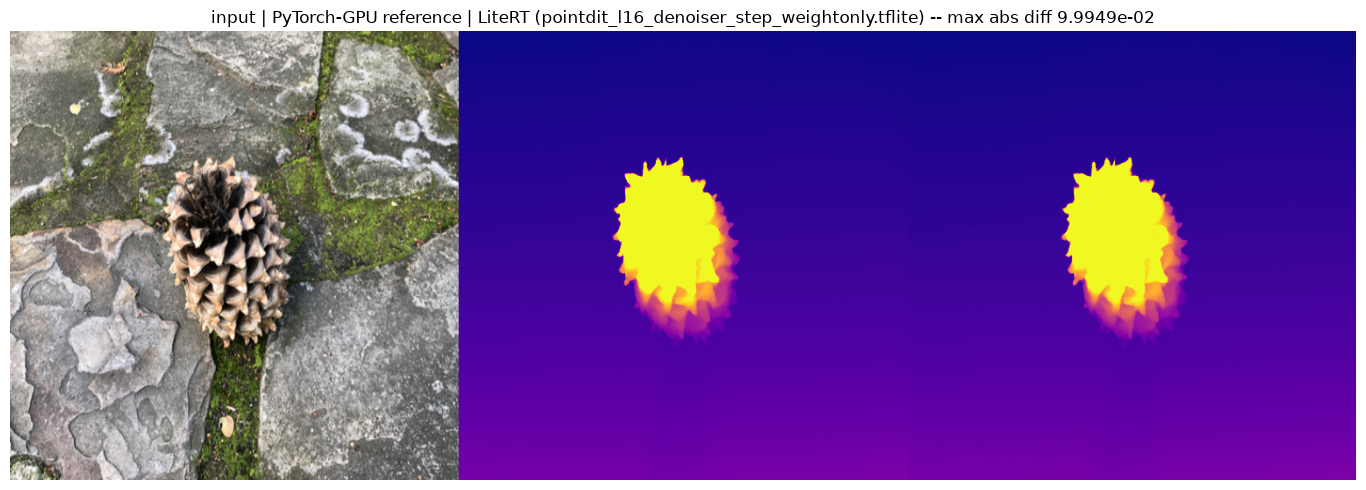

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 5))
ax.imshow(concat)
ax.set_title(f"input | PyTorch-GPU reference | LiteRT ({Path(tflite_path).name}) "
             f"-- max abs diff {max_diff:.4e}")
ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Export to GLB + an interactive `<model-viewer>` HTML page

`save_single_point_cloud` already writes via `trimesh.PointCloud(...).export(filename)`, which
dispatches the actual file format from the extension -- so it already writes a real `.glb` with
zero new export logic, just a different extension (see `tools/litert/run_multiview_merge.py`
section 11 for the same finding verified in more detail, and `research-repo-bringup` skill for
where this was originally established).

In [11]:
save_single_point_cloud(litert_pointcloud[0].transpose(1, 2, 0), arr,
                         filename=f"{out_dir}/{stem}_litert_pointcloud.glb")

html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>PointDiT-{model_size}/16 LiteRT output</title>
<style>
  html, body {{ margin: 0; height: 100%; background: #ffffff; }}
  model-viewer {{ width: 100%; height: 100%; --poster-color: #ffffff; }}
</style>
<script type="module" src="https://unpkg.com/@google/model-viewer/dist/model-viewer.min.js"></script>
</head>
<body>
<model-viewer src="{stem}_litert_pointcloud.glb" alt="PointDiT-{model_size}/16 LiteRT output"
              camera-controls auto-rotate exposure="1.0"
              environment-image="neutral" shadow-intensity="0">
</model-viewer>
</body>
</html>
"""
html_path = f"{out_dir}/{stem}_litert_pointcloud.html"
Path(html_path).write_text(html)
print(f"Wrote {out_dir}/{stem}_litert_pointcloud.glb and {html_path}.")
print(f"Serve it, don't double-click it: a bare file:// open blocks model-viewer's fetch() of "
      f"the sibling .glb with a CORS error (confirmed live -- see run_multiview_merge.py section "
      f"11 and the research-repo-bringup skill). Run e.g. "
      f"`python -m http.server -d {out_dir} 8000` and open http://127.0.0.1:8000/{stem}_litert_pointcloud.html")

Wrote generation/litert_inference/IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_litert_pointcloud.glb and generation/litert_inference/IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_litert_pointcloud.html.
Serve it, don't double-click it: a bare file:// open blocks model-viewer's fetch() of the sibling .glb with a CORS error (confirmed live -- see run_multiview_merge.py section 11 and the research-repo-bringup skill). Run e.g. `python -m http.server -d generation/litert_inference 8000` and open http://127.0.0.1:8000/IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_litert_pointcloud.html


### A single, self-contained file -- for downloading straight to a phone

The version above needs the `.glb` served alongside it. Embedding the GLB as a base64 `data:`
URI instead makes one self-contained file that opens correctly straight from a `file://` open
(a downloaded email/cloud-storage attachment, tapped open on a phone) -- no server, no sibling
file. See `run_multiview_merge.py` section 11 for the full writeup (why this is needed, and its
real size cost: base64 inflates the GLB by ~33% as embedded text).

In [12]:
import base64

glb_b64 = base64.b64encode(Path(f"{out_dir}/{stem}_litert_pointcloud.glb").read_bytes()).decode("ascii")
standalone_html = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>PointDiT-{model_size}/16 LiteRT output</title>
<style>
  html, body {{ margin: 0; height: 100%; background: #ffffff; }}
  model-viewer {{ width: 100%; height: 100%; --poster-color: #ffffff; }}
</style>
<script type="module" src="https://unpkg.com/@google/model-viewer/dist/model-viewer.min.js"></script>
</head>
<body>
<model-viewer src="data:model/gltf-binary;base64,{glb_b64}" alt="PointDiT-{model_size}/16 LiteRT output"
              camera-controls auto-rotate exposure="1.0"
              environment-image="neutral" shadow-intensity="0">
</model-viewer>
</body>
</html>
"""
standalone_html_path = f"{out_dir}/{stem}_litert_pointcloud_standalone.html"
Path(standalone_html_path).write_text(standalone_html)
standalone_size_mb = Path(standalone_html_path).stat().st_size / 1e6
print(f"Wrote {standalone_html_path} ({standalone_size_mb:.1f} MB, one file, safe to download/AirDrop/email as-is)")

Wrote generation/litert_inference/IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_litert_pointcloud_standalone.html (5.6 MB, one file, safe to download/AirDrop/email as-is)


## 10. Point-map to mesh (grid triangulation), and the `1kaiser/Q` model-size-reducer

So far every `.glb` above is a bare point cloud (a glTF `POINTS` primitive) -- real, but sparse
dots, not a connected surface. PointDiT's point map is a *regular* per-pixel grid though (not an
unstructured scan), so building a real mesh doesn't need general point-cloud reconstruction
(Poisson/ball-pivoting) -- a standard depth-map grid triangulation (each 2x2 pixel block -> two
triangles) is exact and cheap for this data shape. `depth_flying_points` (already in this repo,
already used by the real demo pipeline for the same purpose) flags pixels that sit at a depth
discontinuity between foreground and background -- any quad touching one of those pixels is
dropped, instead of stretching a triangle across the gap (the classic "flying pixels" artifact).

In [13]:
import trimesh
from util.viz_pointcloud import depth_flying_points


def pointmap_to_mesh(pointmap, rgb_uint8, rtol=0.04):
    """pointmap: (3, H, W) raw XYZ (pre-GL-flip). rgb_uint8: (H, W, 3). Returns a trimesh.Trimesh
    with the same Y/Z GL flip save_single_point_cloud applies, and the same winding both this
    notebook and run_multiview_merge.py use (verified by real render, not derived by hand)."""
    H, W = pointmap.shape[1:]
    flying = depth_flying_points(pointmap[2], rtol=rtol)  # (H, W) bool -- True = bad pixel

    pts = pointmap.transpose(1, 2, 0).copy()
    pts[:, :, 1] *= -1
    pts[:, :, 2] *= -1
    verts = pts.reshape(-1, 3)
    vcolors = rgb_uint8.reshape(-1, 3)

    ii, jj = np.meshgrid(np.arange(H - 1), np.arange(W - 1), indexing="ij")
    idx = lambda r, c: r * W + c
    v00, v01, v10, v11 = idx(ii, jj), idx(ii, jj + 1), idx(ii + 1, jj), idx(ii + 1, jj + 1)
    bad = flying[ii, jj] | flying[ii, jj + 1] | flying[ii + 1, jj] | flying[ii + 1, jj + 1]
    v00, v01, v10, v11 = v00[~bad], v01[~bad], v10[~bad], v11[~bad]

    faces = np.concatenate([
        np.stack([v00, v10, v01], axis=1),
        np.stack([v01, v10, v11], axis=1),
    ], axis=0)
    return trimesh.Trimesh(vertices=verts, faces=faces, vertex_colors=vcolors, process=False)


flying_frac = depth_flying_points(litert_pointcloud[0, 2]).mean()
mesh = pointmap_to_mesh(litert_pointcloud[0], (arr * 255).astype(np.uint8))
mesh_glb_path = f"{out_dir}/{stem}_mesh.glb"
mesh.export(mesh_glb_path)
print(f"mesh: {len(mesh.vertices):,} verts, {len(mesh.faces):,} faces "
      f"({flying_frac:.1%} of pixels flagged as depth discontinuities and excluded)")
print(f"{mesh_glb_path}: {Path(mesh_glb_path).stat().st_size/1e6:.1f} MB "
      f"(vs. {Path(f'{out_dir}/{stem}_litert_pointcloud.glb').stat().st_size/1e6:.1f} MB for the bare point cloud)")

mesh: 262,144 verts, 407,668 faces (11.0% of pixels flagged as depth discontinuities and excluded)
generation/litert_inference/IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_mesh.glb: 9.1 MB (vs. 4.2 MB for the bare point cloud)


### The `1kaiser/Q` "model size reducer" -- `gltfjsx --transform` -- and a real, confirmed gap

[`1kaiser/Q`](https://github.com/1kaiser/Q)'s README documents `npx gltfjsx {file} --transform`
(prune + Draco compression + texture resizing) as the way to shrink a GLB for the web. Applying
it here is a real, honest mixed result, not a clean win:

- It **only works on a real mesh, not a bare point cloud** -- tried directly on this notebook's
  point-cloud GLB and it crashed (`weld` in `@gltf-transform/functions` throws
  `Cannot read properties of null (reading 'getCount')` with no face/index data to weld). The
  mesh built above is a genuine prerequisite for using this tool at all, not just a nicer viewer.
- On the mesh, it worked and cut size roughly in half (9.09MB -> 4.11MB in real testing) --
  but **the compressed output silently fails to render** in the plain CDN `<model-viewer>` build
  used throughout this notebook. Confirmed three independent ways, not just one: (1) `trimesh`
  itself warns `KHR_draco_mesh_compression GLTF extension has no handler, values are placeholder
  zeros` when reading it back; (2) a real headless-Chrome screenshot of the compressed file comes
  back blank; (3) `unpkg.com/@google/model-viewer/dist/model-viewer.min.js` itself contains
  **zero** occurrences of the strings `"draco"` or `"gstatic"` -- this specific CDN build simply
  has no Draco decoder registered at all, so `KHR_draco_mesh_compression` geometry silently
  decodes to nothing.
- **Practical conclusion for this pipeline**: build the mesh (real, working, and already smaller
  than you might expect a mesh to be relative to its source point cloud once flying points are
  dropped), but skip `--transform`'s Draco step until a Draco-decoder-enabled model-viewer build
  is specifically set up and verified -- random point/vertex subsampling (already used elsewhere
  in this repo for the same size-cap problem) is the working alternative today.

127.0.0.1 - - [27/Aug/2026 01:05:14] "GET /IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_mesh_view.html HTTP/1.1" 200 -


127.0.0.1 - - [27/Aug/2026 01:05:15] "GET /IMG_7261_L16_pointdit_l16_denoiser_step_weightonly_mesh.glb HTTP/1.1" 200 -
127.0.0.1 - - [27/Aug/2026 01:05:15] code 404, message File not found
127.0.0.1 - - [27/Aug/2026 01:05:15] "GET /favicon.ico HTTP/1.1" 404 -


mesh screenshot pixel stddev: 34.97


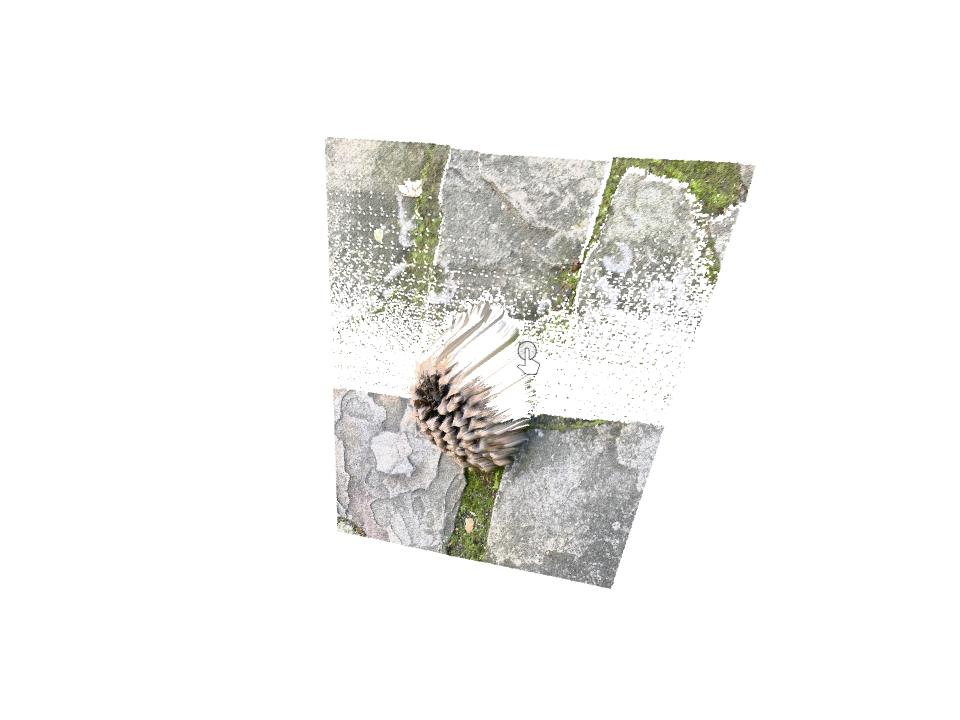

In [14]:
import functools
import http.server
import subprocess
import threading

from IPython.display import Image as IPyImage, display

NODE_BIN = "/home/kaiser/.conda/envs/node20/bin/node"

verify_html = f"""<!DOCTYPE html>
<html><head><meta charset="utf-8">
<script type="module" src="https://unpkg.com/@google/model-viewer/dist/model-viewer.min.js"></script>
<style>html,body{{margin:0;height:100%;background:#fff;}}model-viewer{{width:100%;height:100%;}}</style>
</head><body><model-viewer src="{Path(mesh_glb_path).name}" camera-controls auto-rotate
exposure="1.0" environment-image="neutral" shadow-intensity="0"></model-viewer></body></html>
"""
mesh_view_path = f"{out_dir}/{stem}_mesh_view.html"
Path(mesh_view_path).write_text(verify_html)

# Serve rather than open as file:// -- same CORS reason as run_multiview_merge.py section 11.
handler = functools.partial(http.server.SimpleHTTPRequestHandler, directory=out_dir)
httpd2 = http.server.ThreadingHTTPServer(("127.0.0.1", 0), handler)
threading.Thread(target=httpd2.serve_forever, daemon=True).start()
port2 = httpd2.server_address[1]

mesh_screenshot = f"{out_dir}/{stem}_mesh_screenshot.png"
result = subprocess.run(
    [NODE_BIN, "tools/litert/glb_viewer/verify_modelviewer.js",
     f"http://127.0.0.1:{port2}/{Path(mesh_view_path).name}", mesh_screenshot],
    capture_output=True, text=True,
)
httpd2.shutdown()
if result.returncode != 0:
    print(result.stderr[-1500:])
assert result.returncode == 0
mesh_std = np.asarray(Image.open(mesh_screenshot).convert("RGB")).astype(float).std()
print(f"mesh screenshot pixel stddev: {mesh_std:.2f}")
assert mesh_std > 3.0, "mesh render looks blank"
display(IPyImage(filename=mesh_screenshot))